# Projet Détection de Fraude
## Étape 1 : Exploration des données
Dataset : Credit Card Fraud Detection (Kaggle)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../creditcard.csv")
print(f"Dataset chargé : {df.shape[0]:,} lignes et {df.shape[1]} colonnes")
df.head()

Dataset chargé : 284,807 lignes et 31 colonnes


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("=== INFORMATIONS GÉNÉRALES ===")
df.info()
print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum().sum(), "valeurs manquantes")

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

In [4]:
fraude = df['Class'].value_counts()
taux = df['Class'].value_counts(normalize=True) * 100
print("=== DISTRIBUTION FRAUDE / NON-FRAUDE ===")
print(f"Transactions normales  : {fraude[0]:,} ({taux[0]:.2f}%)")
print(f"Transactions fraudeuses: {fraude[1]:,} ({taux[1]:.2f}%)")

=== DISTRIBUTION FRAUDE / NON-FRAUDE ===
Transactions normales  : 284,315 (99.83%)
Transactions fraudeuses: 492 (0.17%)


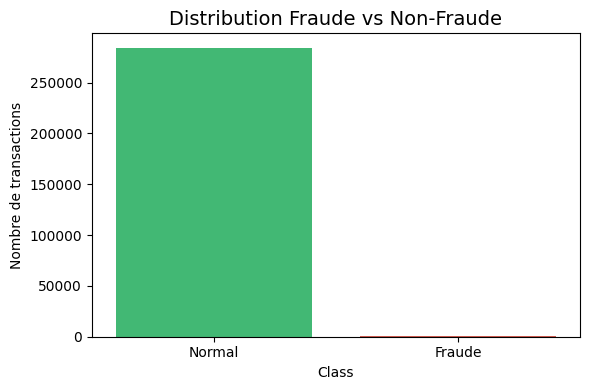

In [5]:
os.makedirs("../reports", exist_ok=True)
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, hue='Class', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribution Fraude vs Non-Fraude', fontsize=14)
plt.xticks([0, 1], ['Normal', 'Fraude'])
plt.ylabel('Nombre de transactions')
plt.tight_layout()
plt.savefig("../reports/class_distribution.png")
plt.show()

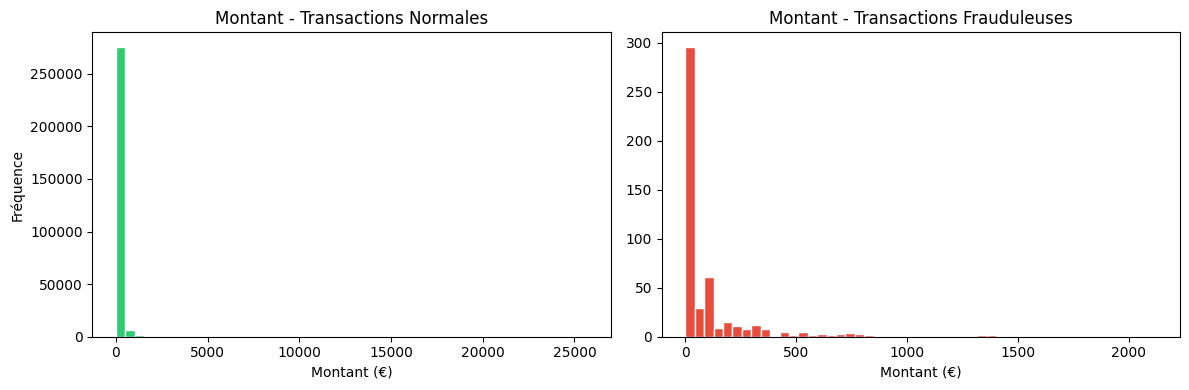

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='#2ecc71', edgecolor='white')
axes[0].set_title('Montant - Transactions Normales')
axes[0].set_xlabel('Montant (€)')
axes[0].set_ylabel('Fréquence')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='#e74c3c', edgecolor='white')
axes[1].set_title('Montant - Transactions Frauduleuses')
axes[1].set_xlabel('Montant (€)')
plt.tight_layout()
plt.savefig("../reports/amount_distribution.png")
plt.show()

In [7]:
print("=" * 50)
print("   RÉSUMÉ EXPLORATION - FRAUD DETECTION")
print("=" * 50)
print(f"Total transactions     : {len(df):,}")
print(f"Transactions normales  : {(df['Class']==0).sum():,} (99.83%)")
print(f"Transactions fraudeuses: {(df['Class']==1).sum():,} (0.17%)")
print(f"Montant moyen normal   : {df[df['Class']==0]['Amount'].mean():.2f}€")
print(f"Montant moyen fraude   : {df[df['Class']==1]['Amount'].mean():.2f}€")
print(f"Montant max fraude     : {df[df['Class']==1]['Amount'].max():.2f}€")
print(f"Valeurs manquantes     : {df.isnull().sum().sum()}")
print("=" * 50)
print("✓ Phase 1 - Exploration terminée !")

   RÉSUMÉ EXPLORATION - FRAUD DETECTION
Total transactions     : 284,807
Transactions normales  : 284,315 (99.83%)
Transactions fraudeuses: 492 (0.17%)
Montant moyen normal   : 88.29€
Montant moyen fraude   : 122.21€
Montant max fraude     : 2125.87€
Valeurs manquantes     : 0
✓ Phase 1 - Exploration terminée !
